# Histopathologic Cancer Detection Project

## Step1: Brief description of the problem and data

This is the week 3 homework: CNN Cancer Detection Kaggle Mini-project for DTSA 5511 (Introduction to Deep Learning).
[Github link](https://github.com/SharronX/DTSA-5511-hw3/blob/main/Histopathologic%20cancer%20detection.ipynb)

The data comes from a [Kaggle](https://www.kaggle.com/competitions/histopathologic-cancer-detection/overview) competition. The goal is to use CNN to classify small pathology images to determine whether they contain tumor tissue. The train dataset contains more than 200k images with already known indicators, while the test dataset contains about 60k images whose indicators are to be determined.

## Step2: Exploratory Data Analysis (EDA)

In [1]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Input

In [2]:
train_labels = pd.read_csv('data/train_labels.csv')

In [3]:
train_labels["filename"] = train_labels["id"].apply(lambda x: os.path.join(r"./data/train/",f"{x}.tif"))
train_labels["label"] = train_labels["label"].astype(str)

In [4]:
train_labels.info

<bound method DataFrame.info of                                               id label  \
0       f38a6374c348f90b587e046aac6079959adf3835     0   
1       c18f2d887b7ae4f6742ee445113fa1aef383ed77     1   
2       755db6279dae599ebb4d39a9123cce439965282d     0   
3       bc3f0c64fb968ff4a8bd33af6971ecae77c75e08     0   
4       068aba587a4950175d04c680d38943fd488d6a9d     0   
...                                          ...   ...   
220020  53e9aa9d46e720bf3c6a7528d1fca3ba6e2e49f6     0   
220021  d4b854fe38b07fe2831ad73892b3cec877689576     1   
220022  3d046cead1a2a5cbe00b2b4847cfb7ba7cf5fe75     0   
220023  f129691c13433f66e1e0671ff1fe80944816f5a2     0   
220024  a81f84895ddcd522302ddf34be02eb1b3e5af1cb     1   

                                                 filename  
0       ./data/train/f38a6374c348f90b587e046aac6079959...  
1       ./data/train/c18f2d887b7ae4f6742ee445113fa1aef...  
2       ./data/train/755db6279dae599ebb4d39a9123cce439...  
3       ./data/train/bc3f0c64fb

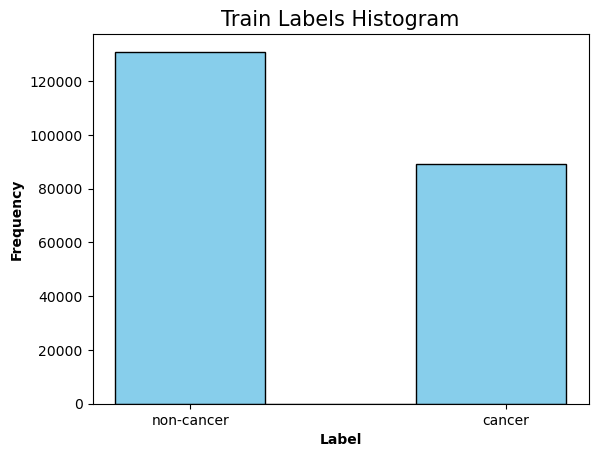

In [5]:
plt.hist(train_labels.label, bins=3, color='skyblue', edgecolor='black', align='left')
plt.title('Train Labels Histogram', fontsize = 15)
plt.xlabel('Label', fontweight ='bold', fontsize = 10)
plt.ylabel('Frequency', fontweight ='bold', fontsize = 10)
plt.xticks([r for r in (0, 0.7)], ['non-cancer', 'cancer'])
plt.show()

In [6]:
def plot_sample_image(label, sample_size, title):
    random_index = train_labels[train_labels['label'] == label].sample(sample_size)
    random_id = random_index['id'].values
    plt.figure(figsize=(15, 5))
    for i in range(len(random_id)):
        img_path = os.path.join('data/train/', f"{random_id[i]}.tif")
        img = Image.open(img_path)
        plt.subplot(1, len(random_id), i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.title(title)
    plt.show()

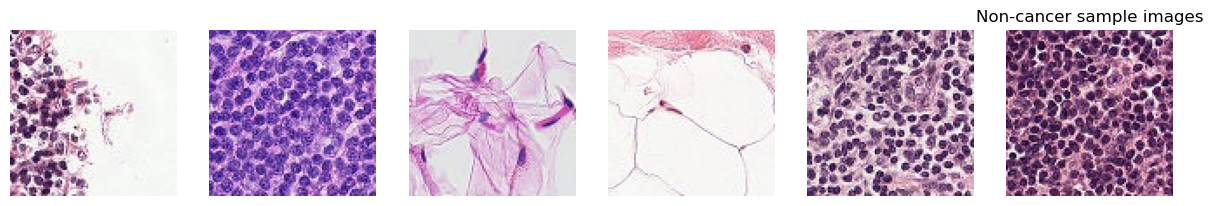

In [7]:
plot_sample_image("0", 6, 'Non-cancer sample images')

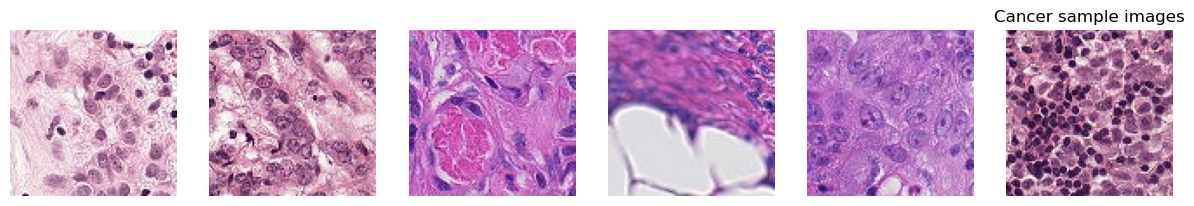

In [8]:
plot_sample_image("1", 6, 'Cancer sample images')

In [9]:
n_train_image = len(os.listdir('./data/train'))
n_test_image = len(os.listdir('./data/test'))
print("There are", n_train_image, "images in train set.")
print("There are", n_test_image, "images in test set.")

There are 220025 images in train set.
There are 57458 images in test set.


In [10]:
datagen = ImageDataGenerator(
    validation_split=0.3,
    rescale=1./255,
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_labels,
    x_col="filename",
    y_col="label",
    target_size=(96, 96),
    color_mode="rgb",
    batch_size=32,
    class_mode="binary",
    subset='training'
)

val_generator = datagen.flow_from_dataframe(
    dataframe=train_labels,
    x_col="filename",
    y_col="label",
    target_size=(96, 96),
    color_mode="rgb",
    batch_size=32,
    class_mode="binary",
    subset='validation'
)

Found 154018 validated image filenames belonging to 2 classes.
Found 66007 validated image filenames belonging to 2 classes.


In [11]:
test_df = pd.read_csv('data/sample_submission.csv')
test_df["filename"] = test_df["id"].apply(lambda x: os.path.join(r"./data/test/",f"{x}.tif"))

test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col=None,
    target_size=(96, 96),
    color_mode="rgb",
    batch_size=32,
    class_mode=None,
    shuffle=False
)

Found 57458 validated image filenames.


### Exploratory Data Analysis (EDA) summary
1. From the training label histogram, the ratio of non-cancer to cancer data is about 3:2. Considering the large amount of data, we can consider this to be a balanced training data.
2. When we plot some sample images, we found that it is difficult to identify tumor tissue from these images alone without professional medical background and training. Therefore a powerful neural network learning model is needed to help determine cancer labels. Since these are image data, a Convolutional Neural Network model is a good choice for handling this problem.
3. To measure model performance and help tune our chosen parameters, we randomly split a 10% subset of the training data into a validation set using ImageDataGenerator.

## Step3: Model Architecture
First, I will try a simple convolutional neural network with only one convolutional layer, one max pooling layer, one dense layer, and one output layer. From there, I want to make the model architecture more complex, adjust hyperparameters, and compare different regularization methods. In addition, I will try to mimic modern CNN model (ResNet) to see if we can get better results.

### CNNModel_1 : 
This is a simple model that uses only one convolutional layer and one max pooling layer for feature extraction. As you can imagine, we won’t get the desired results with this simple model, so I added batch norm as well as dropout for regularization to try to make it better.
![title](CNNModel_1-architecture.png)

In [12]:
# Create the model
CNNmodel_1 = Sequential() 

CNNmodel_1.add(Conv2D(32, kernel_size = (3, 3), input_shape = (96, 96, 3) ))
CNNmodel_1.add(BatchNormalization())
CNNmodel_1.add(Activation('relu'))
CNNmodel_1.add(MaxPooling2D(pool_size = (2, 2))) 
CNNmodel_1.add(Dropout(0.25)) 

CNNmodel_1.add(Flatten()) 
CNNmodel_1.add(Dense(128, activation = 'relu')) 
CNNmodel_1.add(Dropout(0.25)) 
CNNmodel_1.add(Dense(1, activation = 'sigmoid'))

In [13]:
# Compile the model
CNNmodel_1.compile(loss = "binary_crossentropy", optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4), metrics = ['accuracy', tf.keras.metrics.AUC()])
print(CNNmodel_1.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 94, 94, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 94, 94, 32)       128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 94, 94, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 47, 47, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 47, 47, 32)        0         
                                                                 
 flatten (Flatten)           (None, 70688)             0

In [14]:
# Train the model
history_1 = CNNmodel_1.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs = 64,
    validation_data = val_generator,
    validation_steps=len(val_generator),
).history

Epoch 1/64
4814/4814 [==============================] - 1271s 264ms/step - loss: 0.5423 - accuracy: 0.7259 - auc: 0.7944 - val_loss: 0.4711 - val_accuracy: 0.7741 - val_auc: 0.8572
Epoch 2/64
4814/4814 [==============================] - 455s 95ms/step - loss: 0.4862 - accuracy: 0.7670 - auc: 0.8386 - val_loss: 0.5031 - val_accuracy: 0.7469 - val_auc: 0.8715
Epoch 3/64
4814/4814 [==============================] - 114s 24ms/step - loss: 0.4582 - accuracy: 0.7857 - auc: 0.8587 - val_loss: 0.4429 - val_accuracy: 0.7926 - val_auc: 0.8877
Epoch 4/64
4814/4814 [==============================] - 116s 24ms/step - loss: 0.4353 - accuracy: 0.8018 - auc: 0.8745 - val_loss: 0.4751 - val_accuracy: 0.7712 - val_auc: 0.8714
Epoch 5/64
4814/4814 [==============================] - 116s 24ms/step - loss: 0.4200 - accuracy: 0.8114 - auc: 0.8840 - val_loss: 0.4598 - val_accuracy: 0.7768 - val_auc: 0.9036
Epoch 6/64
4814/4814 [==============================] - 114s 24ms/step - loss: 0.4089 - accuracy: 0.815

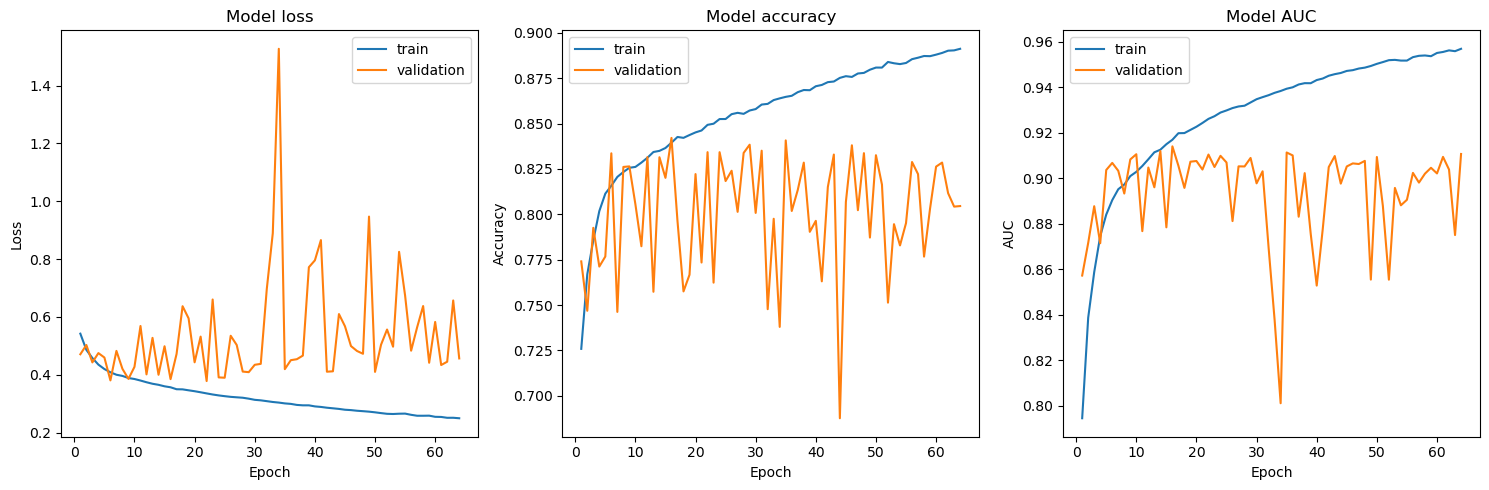

In [15]:
# Evaluate the model
# Plot the loss and accuracy curves for training and validation data

epochs = np.arange(1, len(history_1["val_loss"]) + 1, 1)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(epochs, history_1["loss"], label="train")
axs[0].plot(epochs, history_1["val_loss"], label="validation")
axs[0].set_title('Model loss')
axs[0].set_ylabel('Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend()

axs[1].plot(epochs, history_1["accuracy"], label="train")
axs[1].plot(epochs, history_1["val_accuracy"], label="validation")
axs[1].set_title('Model accuracy')
axs[1].set_ylabel('Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].legend()

axs[2].plot(epochs, history_1["auc"], label="train")
axs[2].plot(epochs, history_1["val_auc"], label="validation")
axs[2].set_title('Model AUC')
axs[2].set_ylabel('AUC')
axs[2].set_xlabel('Epoch')
axs[2].legend()

plt.tight_layout()
plt.show()

In [16]:
predictions = CNNmodel_1.predict(test_generator)
test_df1 = test_df.copy()
test_df1 = test_df1.drop(columns=["filename"])
test_df1["label"]= (predictions > 0.5).astype("int32")
test_df1.to_csv("my_submission_CNNModel_1.csv", index=False)

1796/1796 [==============================] - 380s 212ms/step


In [17]:
CNNmodel_1.save("CNNmodel_1.h5", save_format='h5')

Results: ![title](CNNModel_1-submission.png) 
From the figure, we can see that within 64 epochs, the training curve continues to improve, while the validation curve continues to fluctuate without much improvement, which may indicate that the model is overfitting the training data. In addition, the AUC score of the test set is only 0.76, which does not meet our expectations. Also, there are too many parameters (total parameters: 9,049,345). Let's see if using more conv2d layers will give better results.


### CNNModel_2 :
To improve, CNNModel_2 adds a conv2d layer and a max pooling layer on top of CNNModel_1. BatchNorm and Dropout are still retained in each layer.
![title](CNNModel_2-architecture.png)

In [18]:
# Create the model
CNNmodel_2 = Sequential() 

CNNmodel_2.add(Conv2D(32, kernel_size = (3, 3), input_shape = (96, 96, 3) ))
CNNmodel_2.add(BatchNormalization())
CNNmodel_2.add(Activation('relu'))
CNNmodel_2.add(MaxPooling2D(pool_size = (2, 2))) 
CNNmodel_2.add(Dropout(0.25)) 

CNNmodel_2.add(Conv2D(64, kernel_size = (3, 3) ))
CNNmodel_2.add(BatchNormalization())
CNNmodel_2.add(Activation('relu'))
CNNmodel_2.add(MaxPooling2D(pool_size = (2, 2))) 
CNNmodel_2.add(Dropout(0.25))

CNNmodel_2.add(Flatten()) 
CNNmodel_2.add(Dense(128, activation = 'relu')) 
CNNmodel_2.add(Dropout(0.25)) 
CNNmodel_2.add(Dense(1, activation = 'sigmoid'))

In [19]:
# Compile the model
CNNmodel_2.compile(loss = "binary_crossentropy", optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4), metrics = ['accuracy', tf.keras.metrics.AUC()])
print(CNNmodel_2.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 94, 94, 32)        896       
                                                                 
 batch_normalization_1 (Batc  (None, 94, 94, 32)       128       
 hNormalization)                                                 
                                                                 
 activation_1 (Activation)   (None, 94, 94, 32)        0         
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 47, 47, 32)       0         
 2D)                                                             
                                                                 
 dropout_2 (Dropout)         (None, 47, 47, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 45, 45, 64)       

In [20]:
# Train the model
history_2 = CNNmodel_2.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs = 64,
    validation_data = val_generator,
    validation_steps=len(val_generator),
    callbacks = [tf.keras.callbacks.ReduceLROnPlateau()],
).history

Epoch 1/64
4814/4814 [==============================] - 114s 23ms/step - loss: 0.4722 - accuracy: 0.7872 - auc_1: 0.8530 - val_loss: 0.3805 - val_accuracy: 0.8353 - val_auc_1: 0.9117 - lr: 1.0000e-04
Epoch 2/64
4814/4814 [==============================] - 112s 23ms/step - loss: 0.4221 - accuracy: 0.8186 - auc_1: 0.8857 - val_loss: 0.3670 - val_accuracy: 0.8449 - val_auc_1: 0.9182 - lr: 1.0000e-04
Epoch 3/64
4814/4814 [==============================] - 113s 23ms/step - loss: 0.4067 - accuracy: 0.8283 - auc_1: 0.8948 - val_loss: 0.4897 - val_accuracy: 0.7665 - val_auc_1: 0.9166 - lr: 1.0000e-04
Epoch 4/64
4814/4814 [==============================] - 113s 24ms/step - loss: 0.3946 - accuracy: 0.8357 - auc_1: 0.9019 - val_loss: 0.3745 - val_accuracy: 0.8389 - val_auc_1: 0.9224 - lr: 1.0000e-04
Epoch 5/64
4814/4814 [==============================] - 115s 24ms/step - loss: 0.3833 - accuracy: 0.8398 - auc_1: 0.9076 - val_loss: 0.4532 - val_accuracy: 0.8048 - val_auc_1: 0.9079 - lr: 1.0000e-04


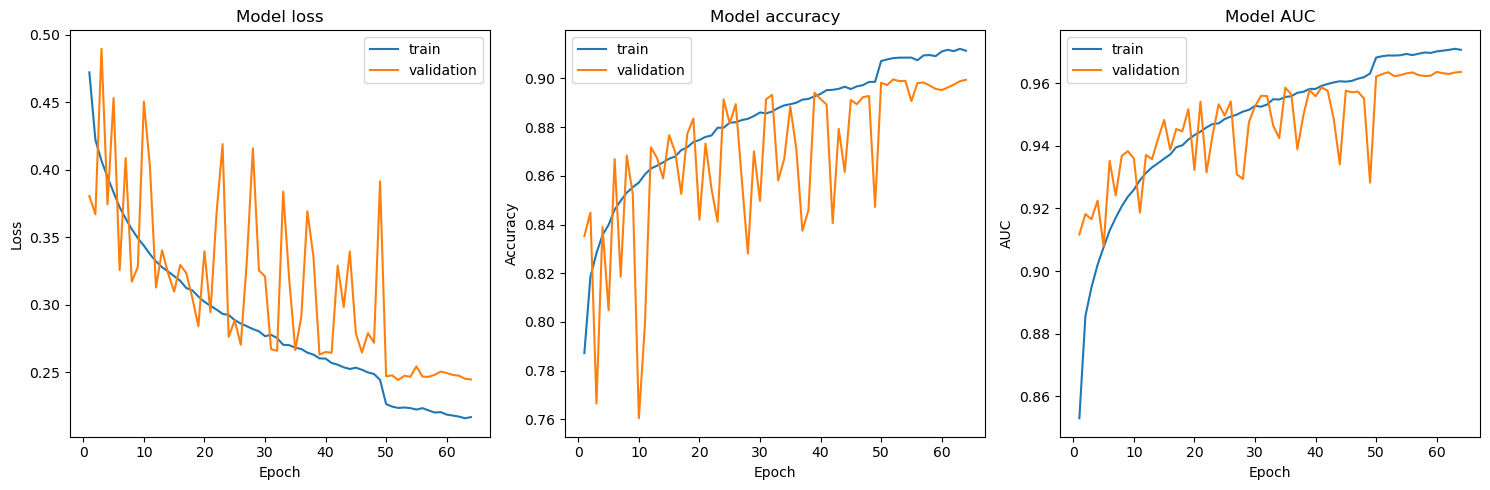

In [21]:
# Evaluate the model
# Plot the loss and accuracy curves for training and validation data

epochs = np.arange(1, len(history_2["val_loss"]) + 1, 1)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(epochs, history_2["loss"], label="train")
axs[0].plot(epochs, history_2["val_loss"], label="validation")
axs[0].set_title('Model loss')
axs[0].set_ylabel('Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend()

axs[1].plot(epochs, history_2["accuracy"], label="train")
axs[1].plot(epochs, history_2["val_accuracy"], label="validation")
axs[1].set_title('Model accuracy')
axs[1].set_ylabel('Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].legend()

axs[2].plot(epochs, history_2["auc_1"], label="train")
axs[2].plot(epochs, history_2["val_auc_1"], label="validation")
axs[2].set_title('Model AUC')
axs[2].set_ylabel('AUC')
axs[2].set_xlabel('Epoch')
axs[2].legend()

plt.tight_layout()
plt.show()

In [22]:
predictions = CNNmodel_2.predict(test_generator)
test_df1 = test_df.copy()
test_df1 = test_df1.drop(columns=["filename"])
test_df1["label"]= (predictions > 0.5).astype("int32")
test_df1.to_csv("my_submission_CNNModel_2.csv", index=False)

1796/1796 [==============================] - 31s 17ms/step


In [23]:
CNNmodel_2.save("CNNmodel_2.h5", save_format='h5')

Results: ![title](CNNModel_2-submission.png) 
The model with two conv2d layers has much fewer parameters (3,984,961 compared to 9,049,345 before). We can see that both the training and validation curves stabilize after 50 epochs. The test AUC is 0.81, which is in line with my expectations.


### CNNModel_3 : 
The previous model used both BatchNorm and Dropout for regularization. In CNNModel_3, I removed Dropout based on the architecture of CNNModel_2 and only used BatchNorm for regularization to compare whether there is a significant difference in performance.

![title](CNNModel_3-architecture.png)

In [24]:
# Create the model
CNNmodel_3 = Sequential() 

CNNmodel_3.add(Conv2D(32, kernel_size = (3, 3), input_shape = (96, 96, 3) ))
CNNmodel_3.add(BatchNormalization())
CNNmodel_3.add(Activation('relu'))
CNNmodel_3.add(MaxPooling2D(pool_size = (2, 2))) 

CNNmodel_3.add(Conv2D(64, kernel_size = (3, 3) ))
CNNmodel_3.add(BatchNormalization())
CNNmodel_3.add(Activation('relu'))
CNNmodel_3.add(MaxPooling2D(pool_size = (2, 2))) 

CNNmodel_3.add(Flatten()) 
CNNmodel_3.add(Dense(128)) 
CNNmodel_3.add(BatchNormalization())
CNNmodel_3.add(Activation('relu'))
CNNmodel_3.add(Dense(1, activation = 'sigmoid'))

In [25]:
# Compile the model
CNNmodel_3.compile(loss = "binary_crossentropy", optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4), metrics = ['accuracy', tf.keras.metrics.AUC()])
print(CNNmodel_3.summary())

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 94, 94, 32)        896       
                                                                 
 batch_normalization_3 (Batc  (None, 94, 94, 32)       128       
 hNormalization)                                                 
                                                                 
 activation_3 (Activation)   (None, 94, 94, 32)        0         
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 47, 47, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 45, 45, 64)        18496     
                                                                 
 batch_normalization_4 (Batc  (None, 45, 45, 64)      

In [26]:
# Train the model
history_3 = CNNmodel_3.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs = 64,
    validation_data = val_generator,
    validation_steps=len(val_generator),
    callbacks = [tf.keras.callbacks.ReduceLROnPlateau()],
).history

Epoch 1/64
4814/4814 [==============================] - 117s 24ms/step - loss: 0.3870 - accuracy: 0.8297 - auc_2: 0.9012 - val_loss: 0.3877 - val_accuracy: 0.8314 - val_auc_2: 0.9217 - lr: 1.0000e-04
Epoch 2/64
4814/4814 [==============================] - 116s 24ms/step - loss: 0.3253 - accuracy: 0.8617 - auc_2: 0.9317 - val_loss: 0.3714 - val_accuracy: 0.8384 - val_auc_2: 0.9304 - lr: 1.0000e-04
Epoch 3/64
4814/4814 [==============================] - 118s 24ms/step - loss: 0.2846 - accuracy: 0.8816 - auc_2: 0.9482 - val_loss: 0.3190 - val_accuracy: 0.8666 - val_auc_2: 0.9388 - lr: 1.0000e-04
Epoch 4/64
4814/4814 [==============================] - 119s 25ms/step - loss: 0.2452 - accuracy: 0.9007 - auc_2: 0.9620 - val_loss: 0.3548 - val_accuracy: 0.8532 - val_auc_2: 0.9256 - lr: 1.0000e-04
Epoch 5/64
4814/4814 [==============================] - 120s 25ms/step - loss: 0.2037 - accuracy: 0.9199 - auc_2: 0.9741 - val_loss: 0.3671 - val_accuracy: 0.8493 - val_auc_2: 0.9291 - lr: 1.0000e-04


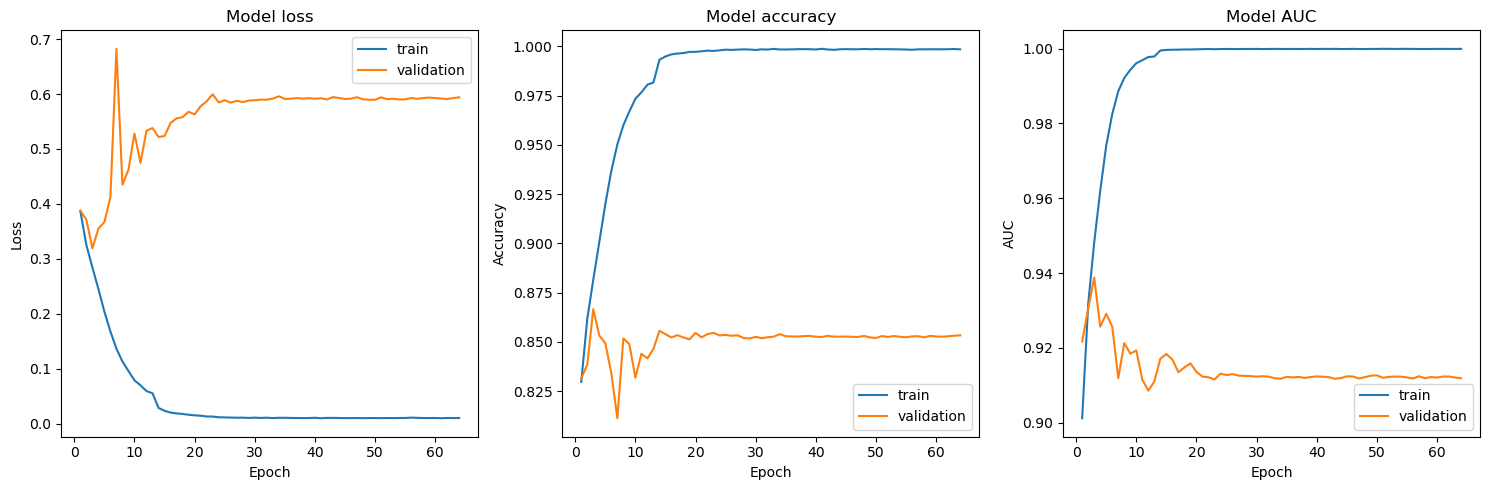

In [27]:
# Evaluate the model
# Plot the loss and accuracy curves for training and validation data

epochs = np.arange(1, len(history_3["val_loss"]) + 1, 1)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(epochs, history_3["loss"], label="train")
axs[0].plot(epochs, history_3["val_loss"], label="validation")
axs[0].set_title('Model loss')
axs[0].set_ylabel('Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend()

axs[1].plot(epochs, history_3["accuracy"], label="train")
axs[1].plot(epochs, history_3["val_accuracy"], label="validation")
axs[1].set_title('Model accuracy')
axs[1].set_ylabel('Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].legend()

axs[2].plot(epochs, history_3["auc_2"], label="train")
axs[2].plot(epochs, history_3["val_auc_2"], label="validation")
axs[2].set_title('Model AUC')
axs[2].set_ylabel('AUC')
axs[2].set_xlabel('Epoch')
axs[2].legend()

plt.tight_layout()
plt.show()

In [28]:
predictions = CNNmodel_3.predict(test_generator)
test_df1 = test_df.copy()
test_df1 = test_df1.drop(columns=["filename"])
test_df1["label"]= (predictions > 0.5).astype("int32")
test_df1.to_csv("my_submission_CNNModel_3.csv", index=False)

1796/1796 [==============================] - 32s 18ms/step


In [29]:
CNNmodel_3.save("CNNmodel_3.h5", save_format='h5')

Results: ![title](CNNModel_3-submission.png) 
Using only Batch Normalization for regularization results in a worse test AUC (only 0.76, similar to the simple model CNNModel_1). And from the loss curve, we can see that model is overfitting the train data. Therefore Dropout is important to prevent overfitting.


### CNNModel_4 : 
Resnet is one of the best performing CNN models in ImageNet, and ResNet-18 is the simplest ResNet architecture, which consists of a series of convolutional layers with skip connections (or residual connections) to make gradients flow more easily during training. The typical ResNet-18 architecture is as follows:

![title](original_ResNet-18.png)

In this model, I tried an architecture similar to ResNet-18, but with much fewer layers than the standard ResNet. The ResNet architecture I imitated is as follows:

![title](CNNModel_4-architecture.png) 


In [30]:
# Create the model
def residual_block(x, filters):
    shortcut = x
    x = Conv2D(filters, kernel_size=(3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, kernel_size=(3,3), padding='same')(x)
    x = BatchNormalization()(x)
    
    # Adding the shortcut connection
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def build_resnet(input_shape, output_classes=1):
    inputs = Input(shape=input_shape)

    # Initial Convolutional Layer
    x = Conv2D(64, kernel_size = (3, 3))(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size = (2, 2))(x)

    # Residual Blocks
    for _ in range(2): # 2 blocks of 64 filters
        x = residual_block(x, 64)

    for _ in range(2): # 2 blocks of 128 filters
        x = Conv2D(128, kernel_size = (1, 1), strides=2, padding='same')(x) # Downsample
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = residual_block(x, 128)

    x = GlobalAveragePooling2D()(x)
    outputs = Dense(output_classes, activation='sigmoid')(x)

    return Model(inputs, outputs)

CNNmodel_4 = build_resnet((96, 96, 3), 1)

In [31]:
# Compile the model
CNNmodel_4.compile(loss = "binary_crossentropy", optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4), metrics = ['accuracy', tf.keras.metrics.AUC()])
print(CNNmodel_4.summary())

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 96, 96, 3)]  0           []                               
                                                                                                  
 conv2d_5 (Conv2D)              (None, 94, 94, 64)   1792        ['input_1[0][0]']                
                                                                                                  
 batch_normalization_6 (BatchNo  (None, 94, 94, 64)  256         ['conv2d_5[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 activation_6 (Activation)      (None, 94, 94, 64)   0           ['batch_normalization_6[0][0]

In [32]:
# Train the model
history_4 = CNNmodel_4.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs = 64,
    validation_data = val_generator,
    validation_steps=len(val_generator),
    callbacks = [tf.keras.callbacks.ReduceLROnPlateau()]
).history

Epoch 1/64
4814/4814 [==============================] - 206s 42ms/step - loss: 0.3109 - accuracy: 0.8686 - auc_3: 0.9381 - val_loss: 0.2525 - val_accuracy: 0.8972 - val_auc_3: 0.9611 - lr: 1.0000e-04
Epoch 2/64
4814/4814 [==============================] - 206s 43ms/step - loss: 0.2024 - accuracy: 0.9216 - auc_3: 0.9731 - val_loss: 0.2194 - val_accuracy: 0.9182 - val_auc_3: 0.9699 - lr: 1.0000e-04
Epoch 3/64
4814/4814 [==============================] - 210s 44ms/step - loss: 0.1641 - accuracy: 0.9381 - auc_3: 0.9819 - val_loss: 0.1803 - val_accuracy: 0.9319 - val_auc_3: 0.9824 - lr: 1.0000e-04
Epoch 4/64
4814/4814 [==============================] - 207s 43ms/step - loss: 0.1371 - accuracy: 0.9493 - auc_3: 0.9872 - val_loss: 0.1669 - val_accuracy: 0.9382 - val_auc_3: 0.9824 - lr: 1.0000e-04
Epoch 5/64
4814/4814 [==============================] - 208s 43ms/step - loss: 0.1141 - accuracy: 0.9585 - auc_3: 0.9909 - val_loss: 0.2741 - val_accuracy: 0.8997 - val_auc_3: 0.9750 - lr: 1.0000e-04


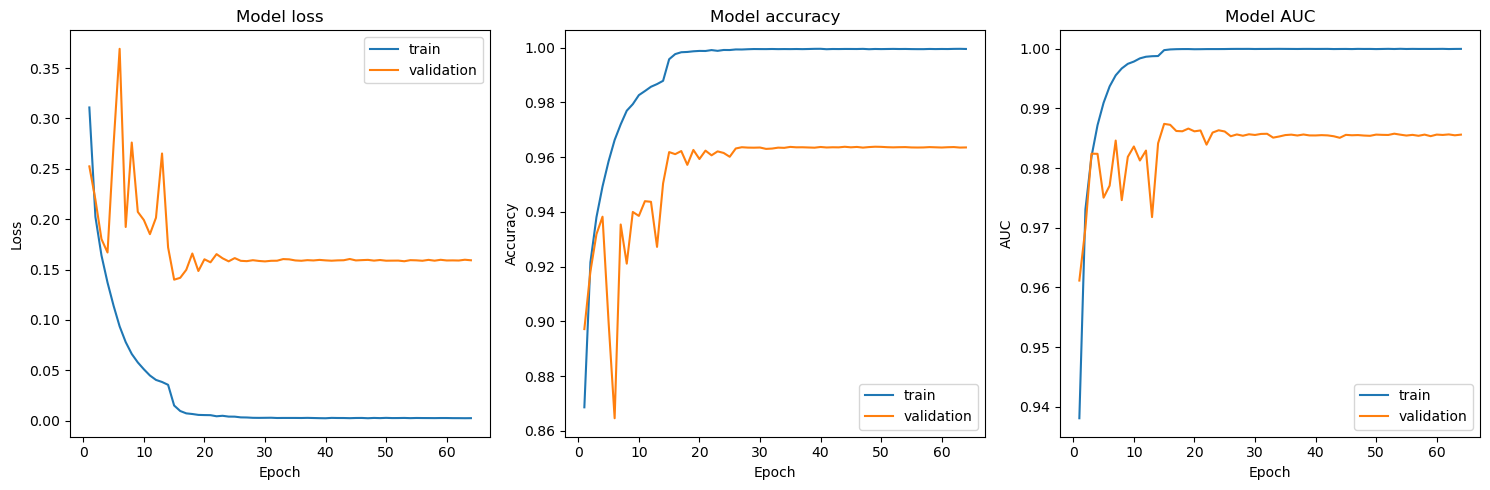

In [33]:
# Evaluate the model
# Plot the loss and accuracy curves for training and validation data

epochs = np.arange(1, len(history_4["val_loss"]) + 1, 1)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(epochs, history_4["loss"], label="train")
axs[0].plot(epochs, history_4["val_loss"], label="validation")
axs[0].set_title('Model loss')
axs[0].set_ylabel('Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend()

axs[1].plot(epochs, history_4["accuracy"], label="train")
axs[1].plot(epochs, history_4["val_accuracy"], label="validation")
axs[1].set_title('Model accuracy')
axs[1].set_ylabel('Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].legend()

axs[2].plot(epochs, history_4["auc_3"], label="train")
axs[2].plot(epochs, history_4["val_auc_3"], label="validation")
axs[2].set_title('Model AUC')
axs[2].set_ylabel('AUC')
axs[2].set_xlabel('Epoch')
axs[2].legend()

plt.tight_layout()
plt.show()

In [34]:
predictions = CNNmodel_4.predict(test_generator)
test_df1 = test_df.copy()
test_df1 = test_df1.drop(columns=["filename"])
test_df1["label"]= (predictions > 0.5).astype("int32")
test_df1.to_csv("my_submission_CNNModel_4.csv", index=False)

1796/1796 [==============================] - 33s 18ms/step


In [35]:
CNNmodel_4.save("CNNmodel_4.h5", save_format='h5')

Results: 

![title](CNNModel_4-submission.png) 

The simulated ResNet model has excellent training and validation performance. Surprisingly, however, the test AUC (0.80) is slightly lower than the previous best performing model CNNModel_2 (0.81), but the difference is not big and is still above 0.8. In addition, it has only 769,153 parameters in total, which makes it less prone to overfitting. Moreover, it only takes about 15 epochs to reach convergence, while CNNModel_2 takes 50 epochs. Therefore, we can say that this simulated ResNet model is the best model so far.


## Step4: Results and Analysis

|Model name|Model detail|train_accuracy|val_accuracy|total params|test score|
|----------|---------|--------|--------|--------|----------|
|CNNModel_1|1 conv + 1 pool + 1 dense (batchnorm + dropout): overfitting|0.8912|0.8046|9,049,345|0.7642|
|CNNModel_2|2 conv + 2 pool + 1 dense (batchnorm + dropout)|0.9114|0.8995|3,984,961|0.8140|
|CNNModel_3|2 conv + 2 pool + 1 dense (batchnorm): overfitting|0.9984|0.8533|3,985,473|0.7617|
|CNNModel_4|Simulated_ResNet-18|0.9995|0.9635|769,153|0.8048|

Comparing the four models, the Simulated_Resnet-18 model has the best performance: excellent training performance, reasonably good test score, and uses much fewer parameters and a shorter convergence time.

## Step5: Conclusion
- In this project, my goal is to build a CNN model that has at least 80% accuracy in detecting cancer in histopathology images. This is obviously a binary classification problem, so I use sigmoid as the output activation function.
- I started by building a very simple CNN model with the minimum number of layers required. From there, I tried tweaking the layers and filters as well as regularization methods to compare performance. The approach of starting with a simple model and gradually increasing its complexity is a widely accepted and popular strategy in machine learning and deep learning.
- Another attempt of mine was to mimic the architecture of a mature ResNet model. Considering the complexity and training time of a typical ResNet model, it was a good idea to reduce some layers and make the architecture simpler. From the results, the simplified ResNet model still performed better than the previous model.

## References

https://towardsdatascience.com/7-ways-to-load-external-data-into-google-colab-7ba73e7d5fc7

https://keras.io/examples/vision/image_classification_from_scratch/

https://www.kaggle.com/code/kanncaa1/convolutional-neural-network-cnn-tutorial

https://www.tutorialspoint.com/keras/keras_convolution_neural_network.htm

https://towardsdatascience.com/understanding-and-visualizing-resnets-442284831be8

https://www.researchgate.net/publication/336642248_A_Deep_Learning_Approach_for_Automated_Diagnosis_and_Multi-Class_Classification_of_Alzheimer%27s_Disease_Stages_Using_Resting-State_fMRI_and_Residual_Neural_Networks